# 04 — Time Series Clustering (STL + DTW)
Categorize products by keyword, decompose daily sales with STL, and cluster seasonal patterns using Dynamic Time Warping.

In [63]:
%matplotlib inline

import re
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from tslearn.clustering import TimeSeriesKMeans
from tslearn.utils import to_time_series_dataset
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent
PROCESSED = PROJECT_ROOT / "data" / "processed" / "online_retail_clean.csv"
FIGURES   = PROJECT_ROOT / "reports" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PROCESSED, parse_dates=["InvoiceDate"])
print(f"Loaded {len(df):,} rows")

Loaded 530,104 rows


C:\Users\powell\AppData\Local\Temp\ipykernel_46340\1704873223.py:20: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(PROCESSED, parse_dates=["InvoiceDate"])


In [64]:
# Define keyword-based product categories derived from top-selling descriptions.
# Each product is assigned to the FIRST matching category (priority order).
# More specific patterns come first to avoid being swallowed by broader ones.
CATEGORIES = {
    "Lunch":            r"LUNCH",
    "Hot Water Bottle":  r"HOT WATER BOTTLE",
    "Night Light":      r"NIGHT LIGHT",
    "Alarm Clock":      r"ALARM CLOCK",
    "Christmas":        r"CHRISTMAS|XMAS|NOEL",
    "Retrospot":        r"RETROSPOT",
    "T-Light":          r"T-LIGHT|TLIGHT|TEA LIGHT|CANDLE",
    "Heart":            r"HEART",
    "Baking":           r"CAKE|BAKING|COOKIE|MOULD",
    "Bunting":          r"BUNTING",
    "Sign":             r"SIGN",
    "Frame":            r"FRAME",
    "Doormat":          r"DOORMAT",
    "Jam":              r"JAM MAKING|JAM SET",
    "Bag":              r"BAG|SHOPPER",
}


def assign_category(desc):
    """Return the first matching category for a product description, or None."""
    desc_upper = str(desc).upper()
    for cat, pattern in CATEGORIES.items():
        if re.search(pattern, desc_upper):
            return cat
    return None


df["Category"] = df["Description"].apply(assign_category)

cat_counts = df["Category"].value_counts()
print(f"Rows assigned to a category: {df['Category'].notna().sum():,} "
      f"({df['Category'].notna().mean()*100:.1f}%)")
print(f"\nCategory counts:")
print(cat_counts)

Rows assigned to a category: 268,172 (50.6%)

Category counts:
Category
Heart               38393
Sign                35986
Retrospot           31064
Bag                 28780
T-Light             27281
Baking              25812
Christmas           25133
Lunch               18240
Hot Water Bottle     9420
Bunting              6702
Doormat              6341
Frame                6266
Alarm Clock          4427
Jam                  2310
Night Light          2017
Name: count, dtype: int64


In [65]:
# Filter to categorized rows and extract date
cat_df = df.dropna(subset=["Category"]).copy()
cat_df["Date"] = cat_df["InvoiceDate"].dt.date

print(f"Categorized rows: {len(cat_df):,}")
print(f"Date range: {cat_df['Date'].min()} to {cat_df['Date'].max()}")

Categorized rows: 268,172
Date range: 2010-12-01 to 2011-12-09


In [66]:
# Weekly sales aggregation per category
daily = (
    cat_df.groupby(["Date", "Category"])["TotalPrice"]
    .sum()
    .reset_index()
)
daily["Date"] = pd.to_datetime(daily["Date"])

weekly = (
    daily.groupby([pd.Grouper(key="Date", freq="W"), "Category"])["TotalPrice"]
    .sum()
    .reset_index()
)

weekly_pivot = weekly.pivot_table(
    index="Date", columns="Category", values="TotalPrice", fill_value=0
)

print(f"Weekly sales matrix: {weekly_pivot.shape[0]} weeks x {weekly_pivot.shape[1]} categories")
weekly_pivot.head()

Weekly sales matrix: 53 weeks x 15 categories


Category,Alarm Clock,Bag,Baking,Bunting,Christmas,Doormat,Frame,Heart,Hot Water Bottle,Jam,Lunch,Night Light,Retrospot,Sign,T-Light
Date,,,,,,,,,,,,,,,
2010-12-05,2534.77,6577.53,12333.17,953.93,12351.62,2639.25,4539.39,11680.49,11177.72,1249.70,3652.82,831.36,11789.44,9832.32,15396.15
2010-12-12,2950.34,11015.18,19043.28,1646.25,18019.35,5425.53,5140.04,30278.66,22967.32,1730.66,4820.52,483.29,18691.82,17799.12,18734.42
2010-12-19,1583.34,6583.84,14322.59,730.01,8907.88,3306.18,5306.23,14491.72,16853.51,1989.74,4097.31,902.76,12490.75,12530.85,19082.99
2010-12-26,953.73,3539.20,6848.77,535.13,2290.52,1731.36,1391.11,5595.42,12506.07,447.02,2184.70,537.79,6190.69,4548.79,4793.25
2011-01-09,1399.71,8822.63,11105.65,2577.04,715.19,2399.52,2728.51,8974.56,3212.98,552.88,3049.98,227.76,13308.05,7795.65,8011.45


In [67]:
# STL decomposition for each category (period=4 for monthly seasonality on weekly data)
stl_results = {}

for cat in weekly_pivot.columns:
    series = weekly_pivot[cat].astype(float)
    stl = STL(series, period=4, robust=True)
    result = stl.fit()
    stl_results[cat] = result

print(f"STL decomposition complete for {len(stl_results)} categories")

STL decomposition complete for 15 categories


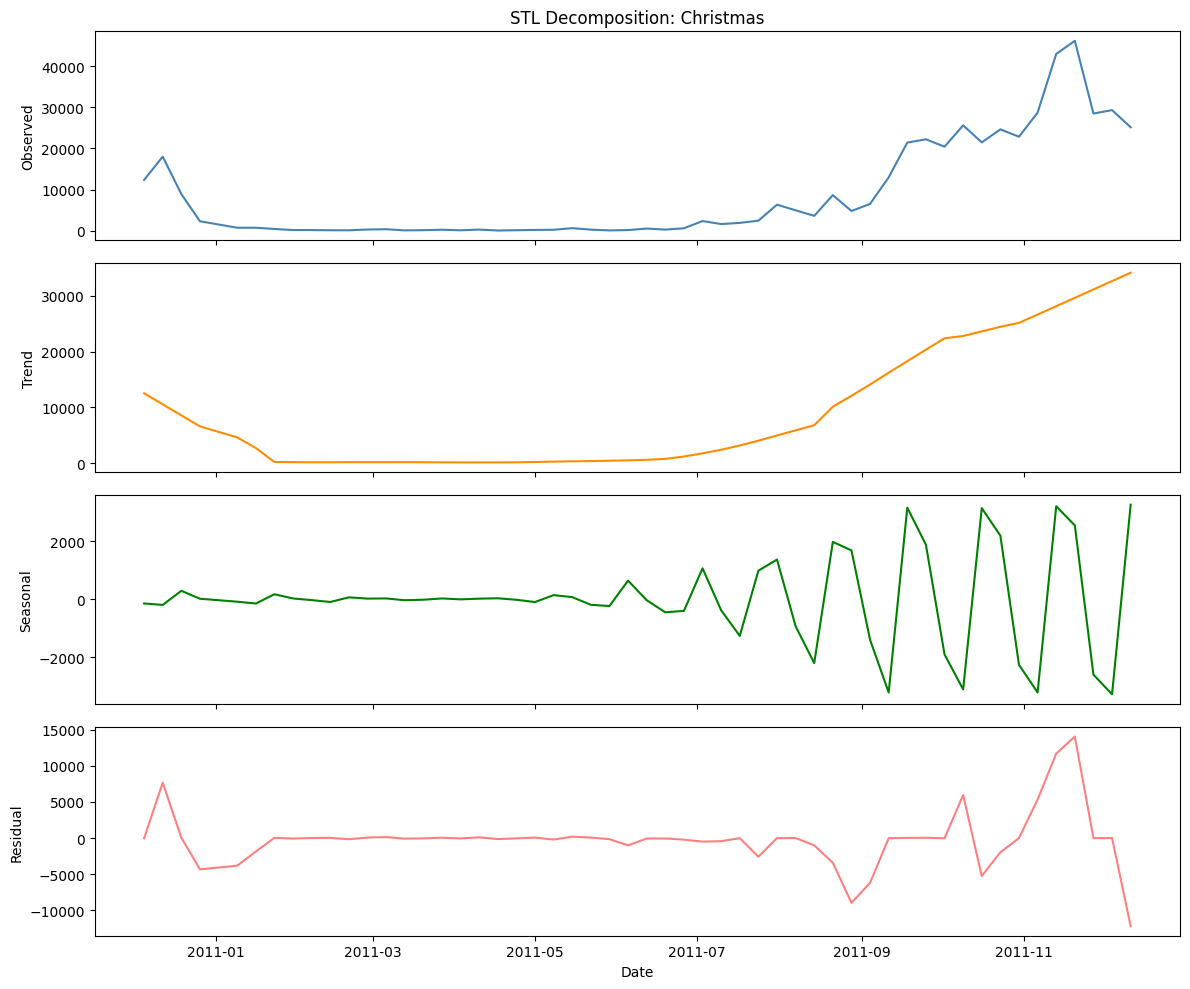

In [68]:
# Example STL decomposition for Christmas category
EXAMPLE_CAT = "Christmas"
result = stl_results[EXAMPLE_CAT]

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(result.observed, color="steelblue")
axes[0].set_ylabel("Observed")
axes[0].set_title(f"STL Decomposition: {EXAMPLE_CAT}")

axes[1].plot(result.trend, color="darkorange")
axes[1].set_ylabel("Trend")

axes[2].plot(result.seasonal, color="green")
axes[2].set_ylabel("Seasonal")

axes[3].plot(result.resid, color="red", alpha=0.5)
axes[3].set_ylabel("Residual")
axes[3].set_xlabel("Date")

plt.tight_layout()
fig.savefig(FIGURES / "ts_stl_example.png", dpi=150)
plt.show()

In [69]:
# Extract seasonal components and normalize
seasonal_matrix = pd.DataFrame(
    {cat: res.seasonal for cat, res in stl_results.items()}
)

print(f"Seasonal matrix shape: {seasonal_matrix.shape}")

# Z-score normalize so DTW compares shape, not magnitude
scaler = StandardScaler()
seasonal_normed = pd.DataFrame(
    scaler.fit_transform(seasonal_matrix),
    index=seasonal_matrix.index,
    columns=seasonal_matrix.columns,
)

print("Normalized seasonal stats (should be ~0 mean, ~1 std):")
print(seasonal_normed.describe().round(2))

Seasonal matrix shape: (53, 15)
Normalized seasonal stats (should be ~0 mean, ~1 std):
       Alarm Clock    Bag  Baking  Bunting  Christmas  Doormat  Frame  Heart  \
count        53.00  53.00   53.00    53.00      53.00    53.00  53.00  53.00   
mean          0.00   0.00    0.00    -0.00      -0.00     0.00  -0.00  -0.00   
std           1.01   1.01    1.01     1.01       1.01     1.01   1.01   1.01   
min          -3.39  -2.50   -2.66    -1.80      -2.07    -1.39  -2.88  -1.97   
25%          -0.48  -0.56   -0.70    -0.76      -0.24    -0.85  -0.30  -0.42   
50%           0.08   0.00    0.13     0.11      -0.01    -0.17  -0.06  -0.13   
75%           0.40   0.56    0.71     0.69       0.18     0.42   0.24   0.29   
max           2.81   2.62    3.50     2.73       2.05     3.13   3.85   4.27   

       Hot Water Bottle    Jam  Lunch  Night Light  Retrospot   Sign  T-Light  
count             53.00  53.00  53.00        53.00      53.00  53.00    53.00  
mean               0.00  -0.00  

In [70]:
# Prepare tslearn dataset: (n_timeseries, n_timestamps, n_features)
ts_data = to_time_series_dataset(
    [seasonal_normed[cat].values for cat in seasonal_normed.columns]
)
cat_names = list(seasonal_normed.columns)

print(f"tslearn dataset shape: {ts_data.shape}")
print(f"Categories: {cat_names}")

tslearn dataset shape: (15, 53, 1)
Categories: ['Alarm Clock', 'Bag', 'Baking', 'Bunting', 'Christmas', 'Doormat', 'Frame', 'Heart', 'Hot Water Bottle', 'Jam', 'Lunch', 'Night Light', 'Retrospot', 'Sign', 'T-Light']


In [71]:
# Elbow and silhouette scores for DTW KMeans
K_RANGE = range(2, 8)
dtw_inertias = []
dtw_sil_scores = []

for k in K_RANGE:
    model = TimeSeriesKMeans(
        n_clusters=k,
        metric="dtw",
        max_iter=30,
        random_state=42,
    )
    labels = model.fit_predict(ts_data)
    dtw_inertias.append(model.inertia_)
    # Silhouette requires at least 2 clusters and 2 members per label
    from sklearn.metrics import silhouette_score as sk_silhouette
    sil = sk_silhouette(ts_data.reshape(ts_data.shape[0], -1), labels)
    dtw_sil_scores.append(sil)
    print(f"k={k}  inertia={model.inertia_:.2f}  silhouette={sil:.4f}")

k=2  inertia=17.32  silhouette=0.0461
k=3  inertia=11.93  silhouette=0.1095
k=4  inertia=9.37  silhouette=0.0663
k=5  inertia=7.85  silhouette=0.0728
k=6  inertia=7.32  silhouette=0.0427
k=7  inertia=5.78  silhouette=0.0312


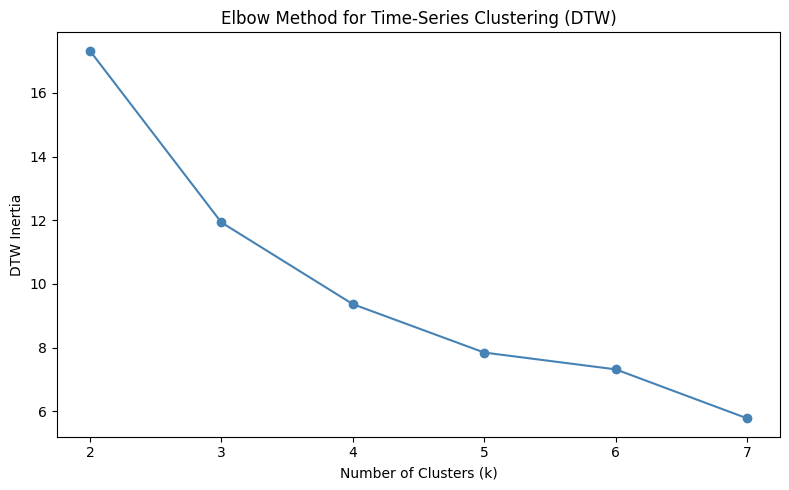

In [72]:
# DTW elbow plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(K_RANGE), dtw_inertias, marker="o", color="steelblue")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("DTW Inertia")
ax.set_title("Elbow Method for Time-Series Clustering (DTW)")
ax.set_xticks(list(K_RANGE))
plt.tight_layout()
fig.savefig(FIGURES / "ts_dtw_elbow.png", dpi=150)
plt.show()

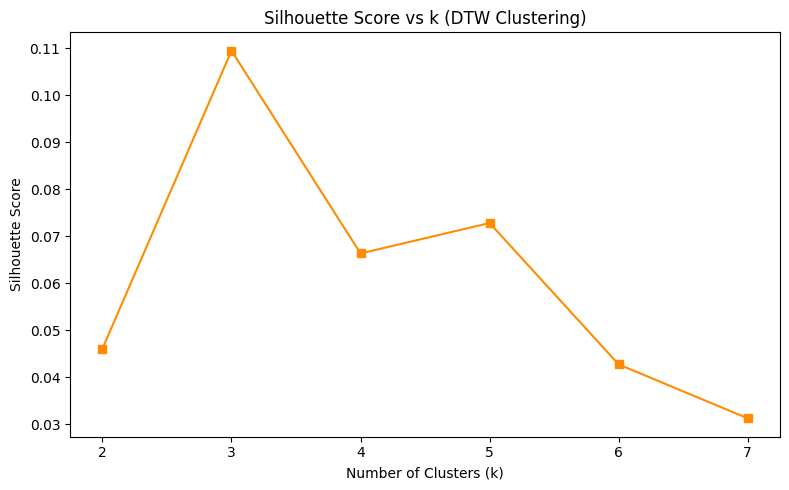

In [73]:
# DTW silhouette score plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(K_RANGE), dtw_sil_scores, marker="s", color="darkorange")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score vs k (DTW Clustering)")
ax.set_xticks(list(K_RANGE))
plt.tight_layout()
fig.savefig(FIGURES / "ts_dtw_silhouette.png", dpi=150)
plt.show()

In [74]:
# Final DTW KMeans with chosen k
BEST_K = 3  # <-- adjust after reviewing elbow/silhouette

model_final = TimeSeriesKMeans(
    n_clusters=BEST_K,
    metric="dtw",
    max_iter=50,
    random_state=42,
)
ts_labels = model_final.fit_predict(ts_data)

cluster_map = {cat: int(label) for cat, label in zip(cat_names, ts_labels)}
print("Category -> Cluster:")
for cat, cl in sorted(cluster_map.items(), key=lambda x: x[1]):
    print(f"  {cat:15s} -> Cluster {cl}")

Category -> Cluster:
  Alarm Clock     -> Cluster 0
  Christmas       -> Cluster 0
  Frame           -> Cluster 0
  Night Light     -> Cluster 0
  Baking          -> Cluster 1
  Heart           -> Cluster 1
  Hot Water Bottle -> Cluster 1
  Jam             -> Cluster 1
  Sign            -> Cluster 1
  Bag             -> Cluster 2
  Bunting         -> Cluster 2
  Doormat         -> Cluster 2
  Lunch           -> Cluster 2
  Retrospot       -> Cluster 2
  T-Light         -> Cluster 2


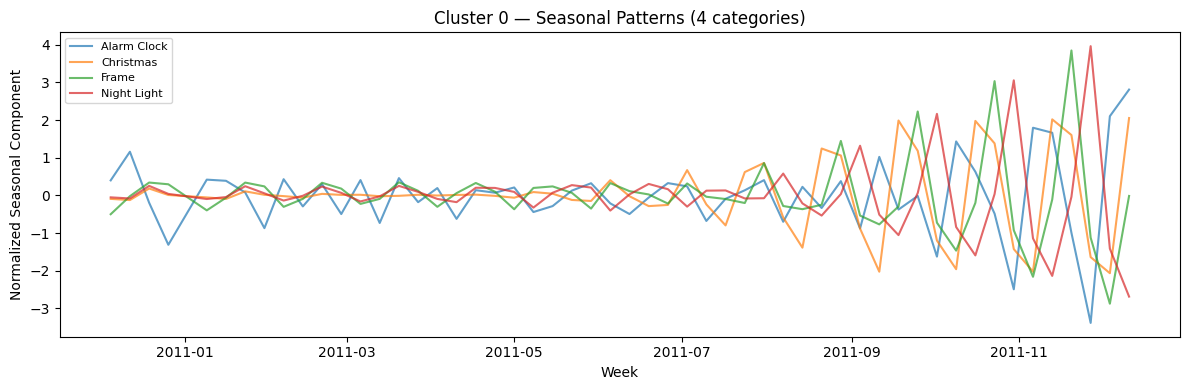

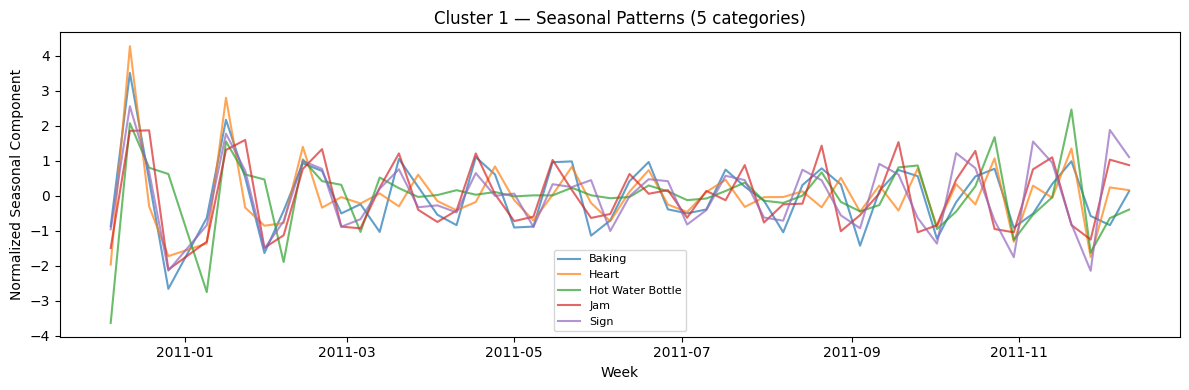

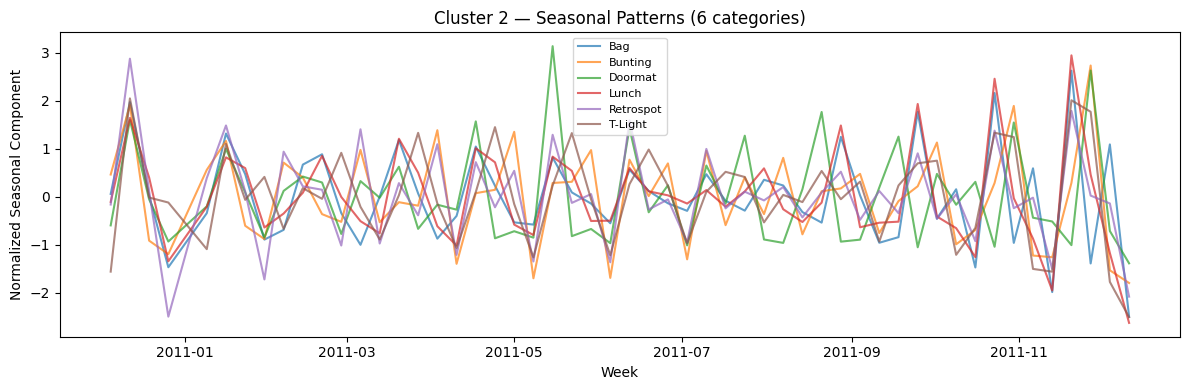

In [75]:
# Seasonal patterns per cluster
for cl in range(BEST_K):
    members = [cat for cat, l in cluster_map.items() if l == cl]
    fig, ax = plt.subplots(figsize=(12, 4))
    for cat in members:
        ax.plot(seasonal_normed.index, seasonal_normed[cat], label=cat, alpha=0.7)
    ax.set_xlabel("Week")
    ax.set_ylabel("Normalized Seasonal Component")
    ax.set_title(f"Cluster {cl} — Seasonal Patterns ({len(members)} categories)")
    ax.legend(fontsize=8)
    plt.tight_layout()
    fig.savefig(FIGURES / f"ts_cluster_{cl}_series.png", dpi=150)
    plt.show()

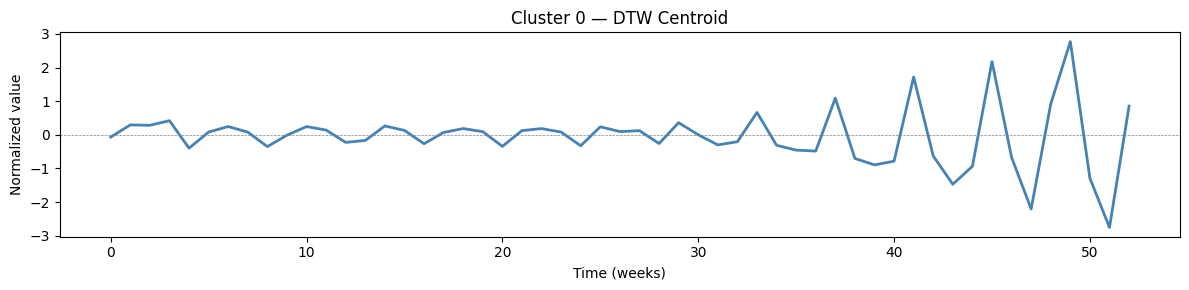

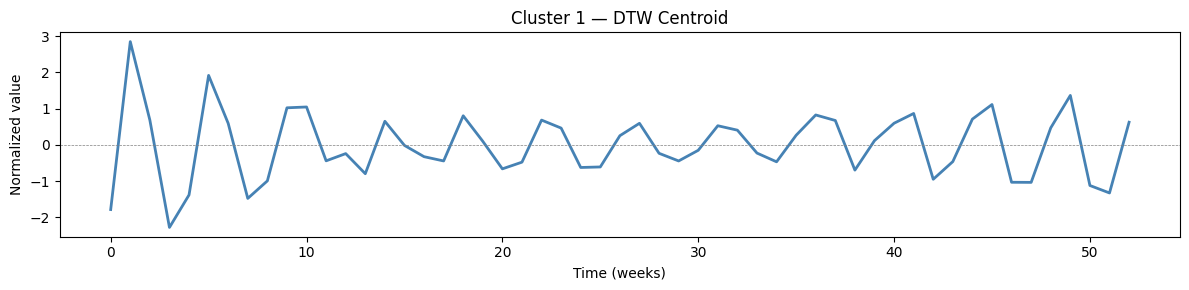

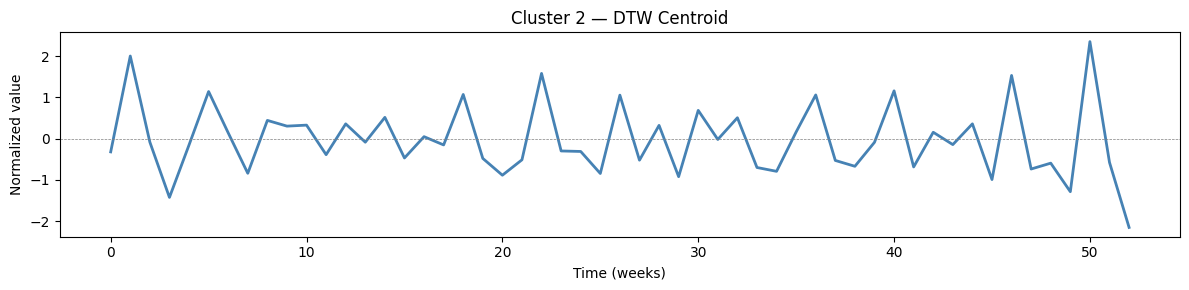

In [76]:
# Cluster centroids
for cl in range(BEST_K):
    center = model_final.cluster_centers_[cl].ravel()
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.plot(center, color="steelblue", linewidth=2)
    ax.set_xlabel("Time (weeks)")
    ax.set_ylabel("Normalized value")
    ax.set_title(f"Cluster {cl} — DTW Centroid")
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.5)
    plt.tight_layout()
    fig.savefig(FIGURES / f"ts_cluster_{cl}_center.png", dpi=150)
    plt.show()

## Interpretation and Mined Insights

Discovery Question: Which product categories share similar seasonal sales patterns?

### Cluster Assignments (k=3)

DTW time-series clustering on the normalized seasonal components from STL decomposition identified 3 clusters, chosen at the highest silhouette score (0.1095):

| Cluster | Categories | Size |
|---|---|---|
| 0 | Alarm Clock, Christmas, Frame, Night Light | 4 |
| 1 | Baking, Heart, Hot Water Bottle, Jam, Sign | 5 |
| 2 | Bag, Bunting, Doormat, Lunch, Retrospot, T-Light | 6 |

### General Insight

- Cluster 0 (4 categories) groups Christmas with 3 other items. These categories share a seasonal pattern characterized by a strong Q4 spike driven by holiday purchases. The other items are electrical appliances or picture frames, which are likely to be purchased mostly during the holiday season.
- *Cluster 1 (5 categories) contains 5 categories including Heart. The items have a moderate holiday seasonal pattern, but also have a very strong Q1 spike. These are most likely to be items that people naturally purchase during the winter time, and not just the holiday season.
- Cluster 2 (6 categories) is the largest group with 6 categories. These represent items with no particular seasonality.

### Business Insight

- Holiday bundle opportunities: Cluster 0 categories peak together in Q4. These are natural candidates for holiday gift bundles or coordinated seasonal promotions.
- Inventory planning: Cluster 0 items need pre-season stocking, while Cluster 2 items can be managed on a steady replenishment cycle. Cluster 1 falls in between, with its own distinct seasonal rhythm to plan around.
- Promotions: Seasonal marketing spend is best concentrated on Cluster 0 (holiday spike) and Cluster 1 (winter/spring items). 